<a href="https://colab.research.google.com/github/lisikxs/-CK-1S/blob/MASTER/CodeCluster1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



---


# Вступление
Датасет взят с сайта Kaggle. Мы его не разрабатывали, лишь взяли для выполнения кода. Данный пример будет использовать для курсовой работы по дисциплине "Основы машинного обучения". Дата создания проекта: 29.03.2025.

И так, работа полностью выполнена двумя студентами: Малич И.А, Сорокина Е.А и Осипов Д.Д. *Это лишь пример выполнения, если используете наш пример, ОЧЕНЬ просим указывать в авторстве нас.* Ниже, будет расписан код и комментарии к нему. Обратите внимание, что используется библиотека **numPy версии 1.23.5.** Это обусловлено тем, что ядро Colab плохо работает с новыми версиями репозитория.

По вопросам сотрудничества/консультации: sahityaSetuq@bk.ru

---



In [ ]:
#использование репозитория/библиотеки кагл нужно для импорта датасета в облако
import kagglehub
yasserh_amazon_product_reviews_dataset_path = kagglehub.dataset_download('yasserh/amazon-product-reviews-dataset')

print('Импорт успешный')

Импорт успешный


In [ ]:
!pip install gensim
!pip install numpy==1.23.5 #это запускается ОДИН РАЗ!!! Больше не надо



---


***Обратите внимание на индекс команд выше. Это не ошибка, это принцип форматирования текста для Bash терминала.***

---



In [ ]:
import numpy as np
import pandas as pd # обработка данных, импорт .csv файлов(если надо работа с pdf)
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from wordcloud import WordCloud
import gensim
from gensim import corpora
from tqdm import tqdm
import warnings
import string
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

warnings.filterwarnings("ignore")

# Загрузите необходимые датасеты NLTK
nltk.download('stopwords')
nltk.download('punkt')
# Файлы входных данных доступны в директории «../input/», доступной только для чтения.
# Например, запустив эту программу (нажав кнопку run или Shift+Enter), вы получите список всех файлов в каталоге input

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/amazon-product-reviews-dataset/7817_1.csv


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
# загружаем
df = pd.read_csv("/kaggle/input/amazon-product-reviews-dataset/7817_1.csv")
df.head()

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,NaN,NaN,Dougal,NaN,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,NaN,NaN,Miljan David Tanic,NaN,NaN,205 grams


# Этап 1.
Мы загрузили все репозитории(библиотеки). Импорт необходимых библиотек

numpy и pandas — основы для численных расчётов и работы с табличными данными (в

том числе чтения CSV и, при желании, PDF).

re — модуль для работы с регулярными выражениями (очистка и манипуляции текстом).

matplotlib.pyplot и seaborn — инструменты для визуализации данных (графики, диаграммы, тепловые карты).

nltk (Natural Language Toolkit) вместе со словарями стоп-слов и токенизатором — фундамент для обработки естественного языка: разбиение текста на слова, удаление «шумовых» слов и базовая лемматизация.

sklearn.feature_extraction.text (CountVectorizer, TfidfVectorizer) и sklearn.decomposition (LatentDirichletAllocation, NMF) — средства для преобразования текстов в числовые матрицы (мешок слов, TF–IDF) и методы тематического моделирования (LDA, NMF).

wordcloud — генерация облаков слов для быстрой визуальной оценки ключевых терминов.

gensim и gensim.corpora — альтернатива scikit-learn для продвинутого анализа тем и моделирования на больших корпусах.

tqdm — индикатор прогресса для долгих циклов (удобно при обучении моделей или массовой обработки текста).

warnings и string — подавление предупреждений и работа с набором знаков препинания.

WordNetLemmatizer — лемматизация слов с опорой на лексическую базу WordNet.

In [ ]:
# показываем начальную информацию
print(f"Dataset Shape: {df.shape}")
df.info()
df.head()

Dataset Shape: (1597, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1597 entries, 0 to 1596
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1597 non-null   object 
 1   asins                 1597 non-null   object 
 2   brand                 1597 non-null   object 
 3   categories            1597 non-null   object 
 4   colors                774 non-null    object 
 5   dateAdded             1597 non-null   object 
 6   dateUpdated           1597 non-null   object 
 7   dimension             565 non-null    object 
 8   ean                   898 non-null    float64
 9   keys                  1597 non-null   object 
 10  manufacturer          965 non-null    object 
 11  manufacturerNumber    902 non-null    object 
 12  name                  1597 non-null   object 
 13  prices                1597 non-null   object 
 14  reviews.date          1217 non-null   object 


,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,NaN,NaN,Dougal,NaN,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,NaN,NaN,Miljan David Tanic,NaN,NaN,205 grams


In [ ]:
# сводная статистика
print("\nСводная статистика:")
print(df.describe(include='all'))


Сводная статистика:
                          id       asins   brand  \
count                   1597        1597    1597   
unique                    66          54       2   
top     AVpfpK8KLJeJML43BCuD  B01BH83OOM  Amazon   
freq                     542         542    1585   
mean                     NaN         NaN     NaN   
std                      NaN         NaN     NaN   
min                      NaN         NaN     NaN   
25%                      NaN         NaN     NaN   
50%                      NaN         NaN     NaN   
75%                      NaN         NaN     NaN   
max                      NaN         NaN     NaN   

                                               categories colors  \
count                                                1597    774   
unique                                                 19      3   
top     Amazon Devices,Home,Smart Home & Connected Liv...  Black   
freq                                                  542    675   
mean          

In [ ]:
df = df[['reviews.text', 'reviews.title']]

In [ ]:
df.tail()

,reviews.text,reviews.title
1592,This is not the same remote that I got for my ...,I would be disappointed with myself if i produ...
1593,I have had to change the batteries in this rem...,Battery draining remote!!!!
1594,"Remote did not activate, nor did it connect to...",replacing an even worse remote. Waste of time
1595,It does the job but is super over priced. I fe...,Overpriced
1596,I ordered this item to replace the one that no...,I am sending all of this crap back to amazon a...




---


# Этап 2.
На этом этапе мы проводим повторную валидацию набора данных уже после того, как избавились от всех столбцов, не несущих ценности для тематического моделирования. Такая *«чистка»* позволяет сфокусироваться исключительно на текстовых признаках и избежать *«шума»* в алгоритмах:

Удалены вспомогательные метаданные (идентификаторы, таймстемпы, URL-ссылки и прочие служебные поля), которые не добавляют информативности к самой теме текста.

Оставлены только ключевые колонки — обычно это столбцы с самим текстом отзывов (или документов) и, при необходимости, с заранее размеченными метками темы.

Проведён быстрый контроль:

Проверяем, что после удаления размер таблицы и число строк совпадают с ожидаемыми.

Убеждаемся, что в оставшихся столбцах нет «пустышек» (пустых значений) и аномалий.

Готовим отфильтрованный корпус к следующим шагам препроцессинга — токенизации, лемматизации и построению матрицы признаков (BoW/TF–IDF).

***Мы получаем максимально «чистый» и компактный датасет, оптимизированный для запуска LDA/NMF и визуальных инструментов (облака слов, тематические распределения) без лишних отвлекающих факторов.***


---



In [ ]:
#Первоначальный анализ данных
print("\nСводная статистика:")
print(df.describe(include='all'))


Сводная статистика:
                                             reviews.text  reviews.title
count                                                1597           1580
unique                                               1048           1270
top     While I've purchased items from Amazon for yea...  Great product
freq                                                   58             16


In [ ]:
# Проверька на недостающие значения и общее качество данных
print("Missing values in each column:")
print(df.isnull().sum())

#Поскольку df содержит только текстовые колонки для моделирования тем, проверьте длину текстовых записей, чтобы оценить качество данных
df['reviews.text_length'] = df['reviews.text'].apply(lambda x: len(x) if pd.notnull(x) else 0)
df['reviews.title_length'] = df['reviews.title'].apply(lambda x: len(x) if pd.notnull(x) else 0)

print("\nReviews text length statistics:")
print(df['reviews.text_length'].describe())

print("\nReviews title length statistics:")
print(df['reviews.title_length'].describe())

Missing values in each column:
reviews.text      0
reviews.title    17
dtype: int64

Reviews text length statistics:
count     1597.000000
mean       909.256105
std       1299.598199
min          3.000000
25%        152.000000
50%        454.000000
75%       1671.000000
max      19739.000000
Name: reviews.text_length, dtype: float64

Reviews title length statistics:
count    1597.000000
mean       57.259236
std        51.244149
min         0.000000
25%        17.000000
50%        34.000000
75%        98.000000
max       207.000000
Name: reviews.title_length, dtype: float64


In [ ]:
# проверка заголовков у отзывов.
df = df.dropna(subset=['reviews.title']).reset_index(drop=True)



---


# Этап 2.А
На этапе очистки текстовой колонки мы готовим «сырой» текст к эффективному анализу — удаляем всё лишнее, приводим слова к единому виду и оставляем только содержательную часть:

Нормализация регистра:
Приводим весь текст к нижнему регистру, чтобы «Apple» и «apple» считались одним токеном.

Удаление «шума»

HTML-теги и разметку: убираем "br", "a href=…" и прочие остатки веб-страниц.

URL-ссылки и e-mail адреса: удаляем или заменяем на плейсхолдеры (например, <URL>).

Спецсимволы, цифры и пунктуацию: очищаем от знаков препинания, скобок, цифр, чтобы не засорять модель.
*P.S. если делаете самостоятельно, то делайте аккуратно. Не удаляйте ВСЁ, потом работать не будет))).*


---



In [ ]:
import re
import spacy
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# загрузка spaCy
nlp = spacy.load('en_core_web_sm')

def clean_text_spacy(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r'\W+', ' ', text)
    text = re.sub(r'\d+', '', text)


    doc = nlp(text)
    tokens = [token.lemma_ for token in doc]


    tokens = [word for word in tokens if word not in stopwords.words('english')]

    return ' '.join(tokens)


df['cleaned_text'] = df['reviews.text'].apply(clean_text_spacy)

# проверяем что мы там наделали
df[['reviews.text', 'cleaned_text']].head()

,reviews.text,cleaned_text
0,I initially had trouble deciding between the p...,I initially trouble decide paperwhite voyage r...
1,Allow me to preface this with a little history...,allow I preface little history I casual reader...
2,I am enjoying it so far. Great for reading. Ha...,I enjoy far great read original fire since f...
3,I bought one of the first Paperwhites and have...,I buy one first paperwhite pleased constant co...
4,I have to say upfront - I don't like coroporat...,I say upfront I like coroporate hermetically c...


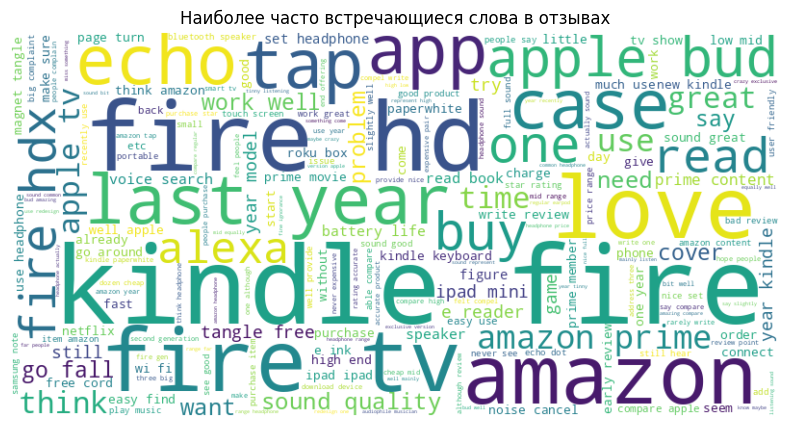

In [ ]:
# ВИЗУАЛИЗАЦИЯ(не меняйте мои настройки, иначе будет непонятно какие слова указаны)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df['cleaned_text']))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Наиболее часто встречающиеся слова в отзывах")
plt.show()

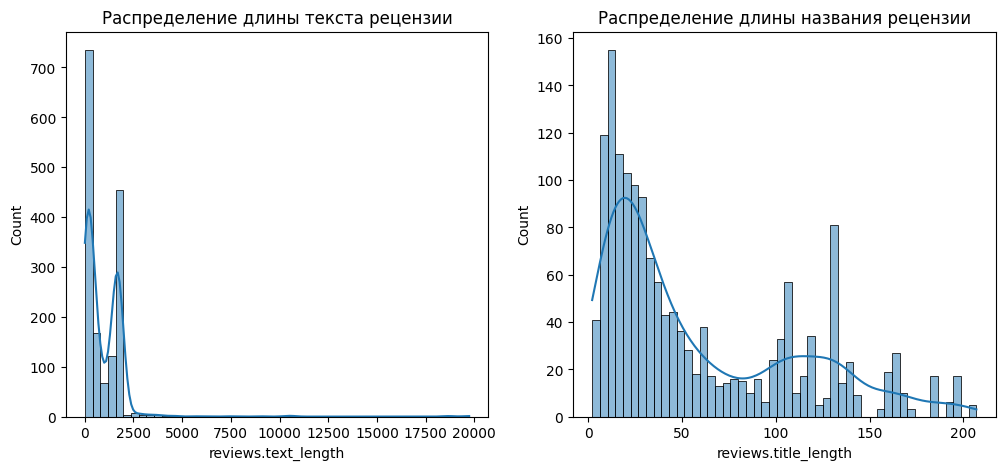

In [ ]:
# Визуализация распределений длины текста
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['reviews.text_length'], bins=50, kde=True, ax=ax[0])
ax[0].set_title("Распределение длины текста рецензии")
sns.histplot(df['reviews.title_length'], bins=50, kde=True, ax=ax[1])
ax[1].set_title("Распределение длины названия рецензии")
plt.show()


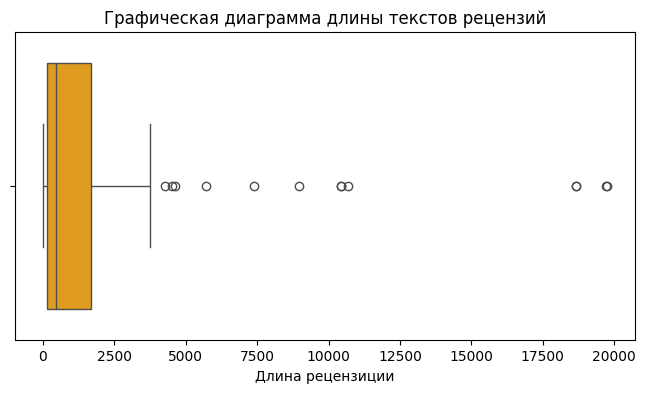

In [ ]:

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['reviews.text_length'], color="orange")
plt.title("Графическая диаграмма длины текстов рецензий")
plt.xlabel("Длина рецензиции")
plt.show()

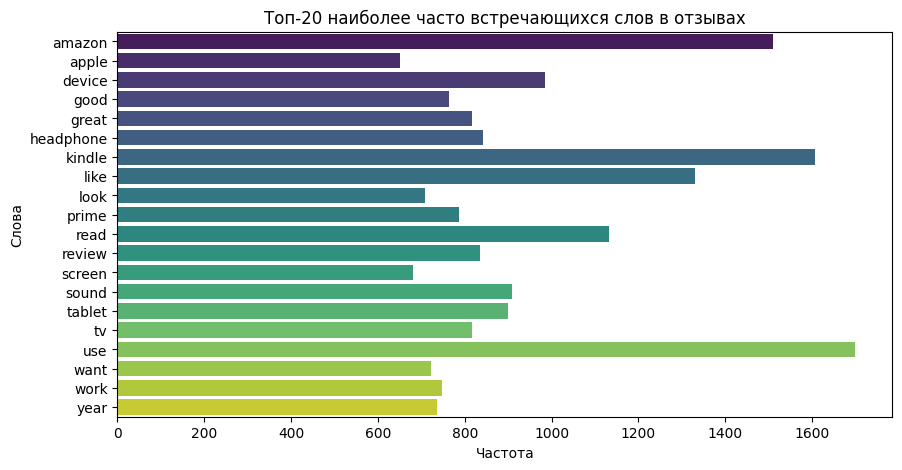

In [ ]:
#Анализ частоты слов
vectorizer = CountVectorizer(stop_words='english', max_features=20)
X = vectorizer.fit_transform(df['cleaned_text'])
word_freq = dict(zip(vectorizer.get_feature_names_out(), X.toarray().sum(axis=0)))
plt.figure(figsize=(10, 5))
sns.barplot(x=list(word_freq.values()), y=list(word_freq.keys()), palette="viridis")
plt.title("Топ-20 наиболее часто встречающихся слов в отзывах")
plt.xlabel("Частота")
plt.ylabel("Слова")
plt.show()

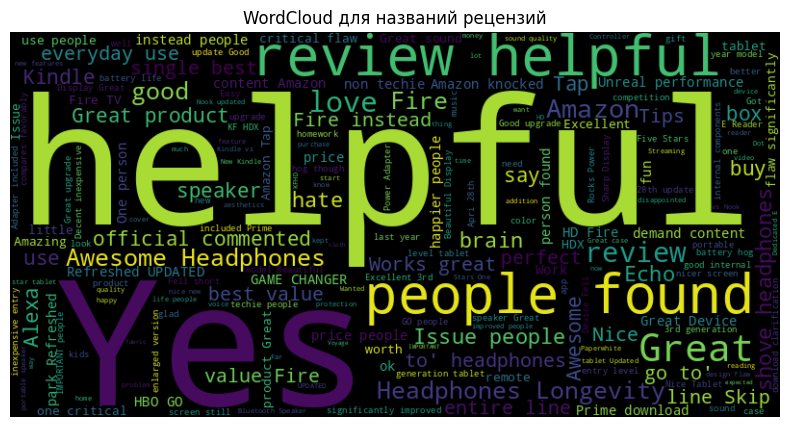

In [ ]:
wordcloud_title = WordCloud(width=800, height=400, background_color='black').generate(' '.join(df['reviews.title'].fillna('')))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_title, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud для названий рецензий")
plt.show()

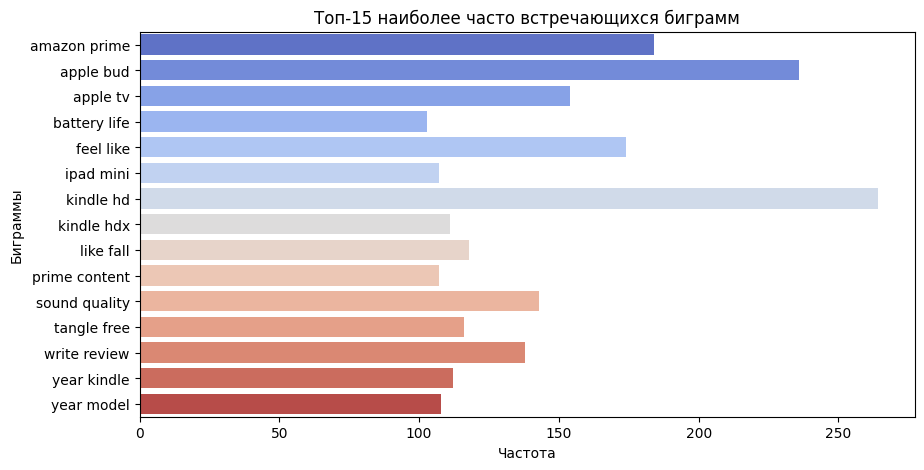

In [ ]:
vectorizer = CountVectorizer(stop_words='english', ngram_range=(2,2), max_features=15)
X = vectorizer.fit_transform(df['cleaned_text'])
bigram_freq = dict(zip(vectorizer.get_feature_names_out(), X.toarray().sum(axis=0)))

plt.figure(figsize=(10, 5))
sns.barplot(x=list(bigram_freq.values()), y=list(bigram_freq.keys()), palette="coolwarm")
plt.title("Топ-15 наиболее часто встречающихся биграмм")
plt.xlabel("Частота")
plt.ylabel("Биграммы")
plt.show()



---


# Этап 3.
Что такое биграммы? N‑граммы в речевой аналитике — это фразы из двух или трех слов, которые операторы и клиенты часто произносят во время звонков. Фразы из двух слов на платформе называют биграммами, из трех — триграммами.
Далее, после выполнения всех частей кода с визуализацией, вы получите диаграммы графики и т.д. Если вдруг они показываются некорректно, советую ребут системы с сохранением переменных. Двигаемся дальше!:)
Далее некоторые диаграммы будут на английском, ибо некоторые функции выводят сразу на английском и никак нельзя переименовать.(
  

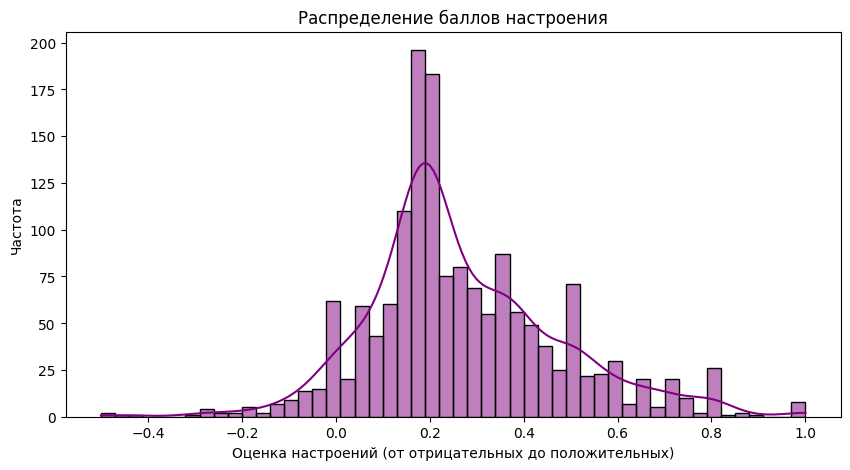

In [ ]:
#  Анализ настроения
from textblob import TextBlob

def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df['sentiment_score'] = df['cleaned_text'].apply(get_sentiment)

plt.figure(figsize=(10, 5))
sns.histplot(df['sentiment_score'], bins=50, kde=True, color="purple")
plt.title("Распределение баллов настроения")
plt.xlabel("Оценка настроений (от отрицательных до положительных)")
plt.ylabel("Частота")
plt.show()

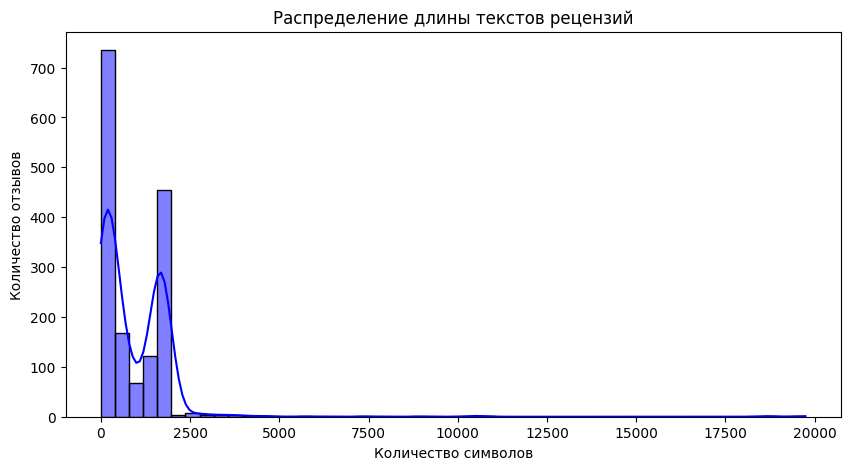

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['reviews.text_length'], bins=50, kde=True, color='blue')
plt.title("Распределение длины текстов рецензий")
plt.xlabel("Количество символов")
plt.ylabel("Количество отзывов")
plt.show()

Не менее важный этап - визуализация выбросов. Далее описание кода.

---


Добавили два новых признака:

Считали, сколько символов в теле отзыва (reviews.text_length)

Считали, сколько символов в заголовке (reviews.title_length)

Построили boxplot-графики (ящики с усами), чтобы увидеть выбросы — слишком короткие или длинные отзывы, которые выбиваются из общего потока.

Построили гистограммы — наглядно посмотрели, как распределены длины отзывов и заголовков (чаще всего текстов больше в районе средней длины).

Посчитали границы выбросов по формуле IQR:

Нашли верхнюю и нижнюю границу, за которую длина текста считается выбросом.

Посчитали, сколько таких "необычных" отзывов есть в данных.

Построили scatter-график — точечную диаграмму, где видно:

как распределены длины всех отзывов;

где находятся границы выбросов;

какие записи выбиваются за них.


---



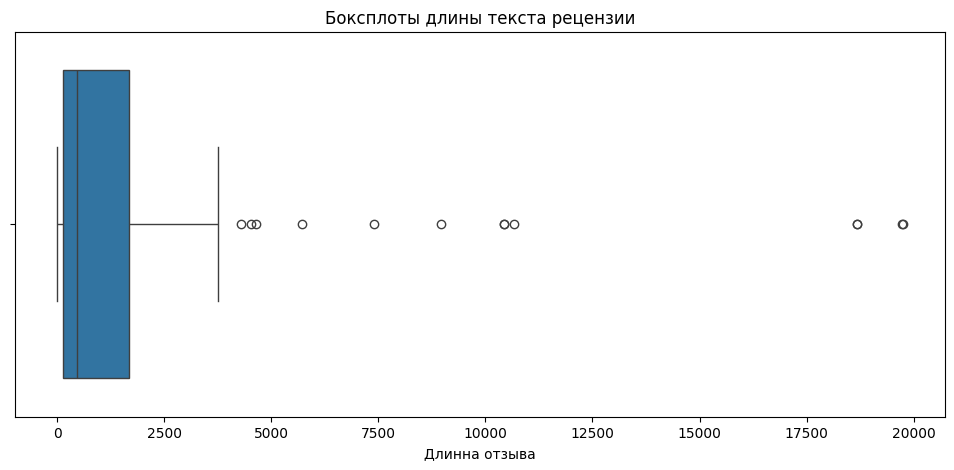

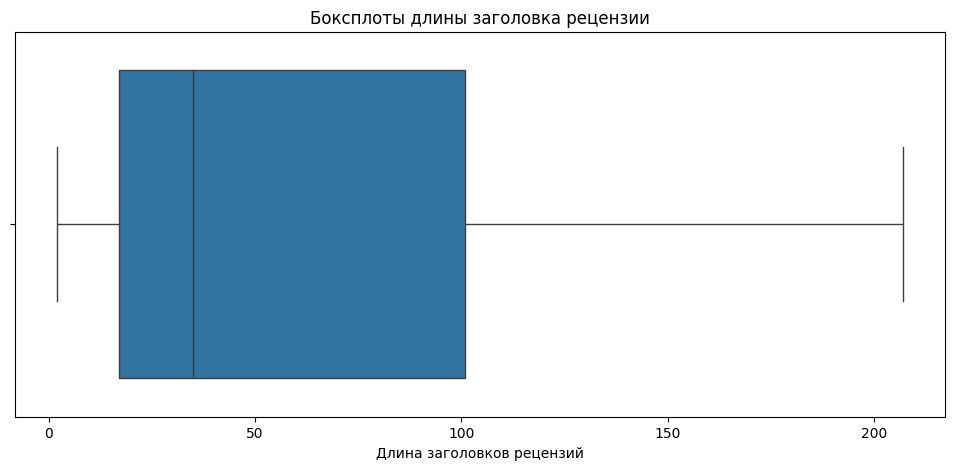

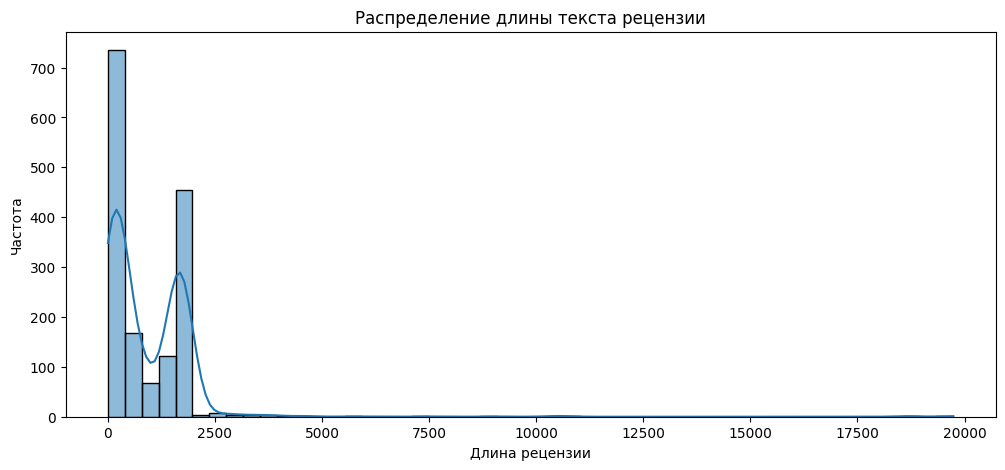

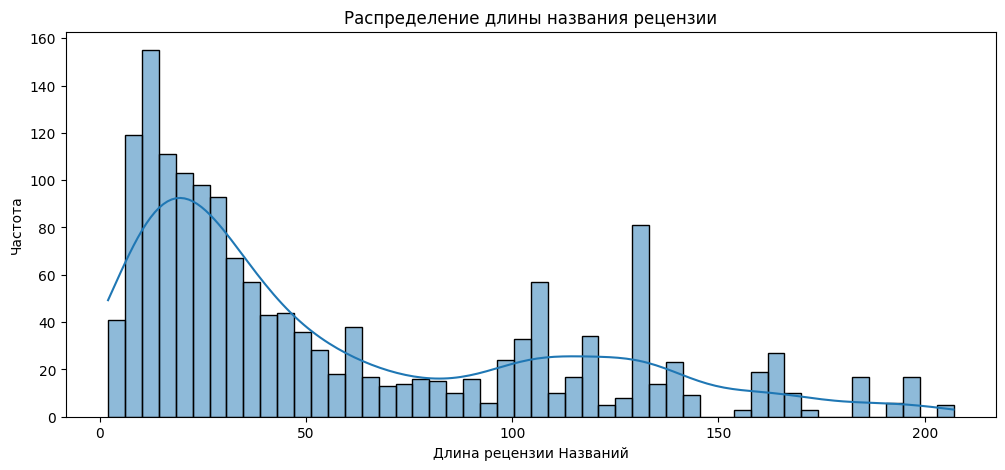

Количество выбросов, обнаруженных в длине текста рецензии: 13


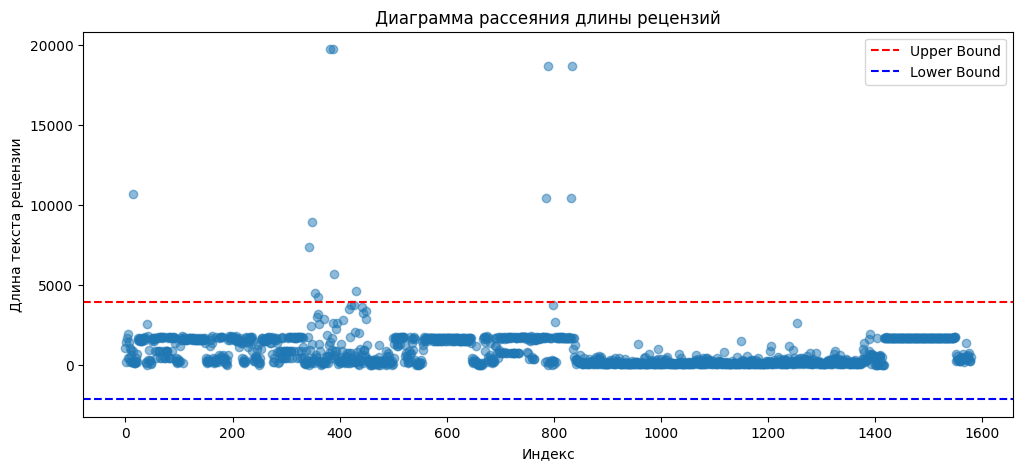

In [ ]:
#визуализация выбросов

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df['reviews.text_length'] = df['reviews.text'].apply(lambda x: len(str(x)))
df['reviews.title_length'] = df['reviews.title'].apply(lambda x: len(str(x)))


plt.figure(figsize=(12, 5))
sns.boxplot(x=df['reviews.text_length'])
plt.title('Боксплоты длины текста рецензии')
plt.xlabel('Длинна отзыва')
plt.show()

#  Боксплот для выявления провалов в длине заголовка рецензии(важно!)
plt.figure(figsize=(12, 5))
sns.boxplot(x=df['reviews.title_length'])
plt.title('Боксплоты длины заголовка рецензии')
plt.xlabel('Длина заголовков рецензий')
plt.show()


plt.figure(figsize=(12, 5))
sns.histplot(df['reviews.text_length'], bins=50, kde=True)
plt.title('Распределение длины текста рецензии')
plt.xlabel('Длина рецензии')
plt.ylabel('Частота')
plt.show()


plt.figure(figsize=(12, 5))
sns.histplot(df['reviews.title_length'], bins=50, kde=True)
plt.title('Распределение длины названия рецензии')
plt.xlabel('Длина рецензии Названий')
plt.ylabel('Частота')
plt.show()

# Обнаружение выбросов с помощью метода IQR
Q1 = df['reviews.text_length'].quantile(0.25)
Q3 = df['reviews.text_length'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['reviews.text_length'] < lower_bound) | (df['reviews.text_length'] > upper_bound)]
print(f"Количество выбросов, обнаруженных в длине текста рецензии: {outliers.shape[0]}")


plt.figure(figsize=(12, 5))
plt.scatter(df.index, df['reviews.text_length'], alpha=0.5)
plt.axhline(y=upper_bound, color='r', linestyle='dashed', label='Upper Bound')
plt.axhline(y=lower_bound, color='b', linestyle='dashed', label='Lower Bound')
plt.title('Диаграмма рассеяния длины рецензий')
plt.xlabel('Индекс')
plt.ylabel('Длина текста рецензии')
plt.legend()
plt.show()


# Краткое пояснение!
Это метод, который помогает автоматически определить «слишком большие» или «слишком маленькие» значения (выбросы) на основе разбивки данных на квартиля:

Квартиль

Q1 (первый квартиль) — медиана нижней половины данных, 25 % значений лежат ниже него.

Q3 (третий квартиль) — медиана верхней половины данных, 75 % значений лежат ниже него.

Межквартильный размах (IQR)

IQR=Q3−Q1

Это «ширина» среднего 50 % распределения.

Границы выбросов

Нижняя граница = Q1−1,5×IQR

Верхняя граница = Q3+1,5×IQR

Определение выбросов:
Любые значения, которые оказались меньше нижней границы или больше верхней, считаются статистическими выбросами.

# Этап 4. Финал

In [ ]:
# Векторизация очищенного текста с помощью TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_text'])

# указывает количество тем
num_topics = 5

# LDA model
lda = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda.fit(tfidf_matrix)


def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx+1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))
        print()


display_topics(lda, tfidf_vectorizer.get_feature_names_out(), 10)

Topic 1:
headphone ear sound bud like apple earbud comcast people magnet

Topic 2:
kindle fire read tablet book hdx paperwhite screen hd year

Topic 3:
great echo tap love speaker alexa sound use work amazon

Topic 4:
tv prime roku content box device fire apple thank movie

Topic 5:
fire smartphone samsung tablet review early gen first reader note



In [ ]:

topic_distributions = lda.transform(tfidf_matrix)
df['topic'] = topic_distributions.argmax(axis=1) + 1  # добавочное число к теме

# название подзаголовков
topic_labels = {
    1: "Наушники",
    2: "Колонки и голосовые ассистенты",
    3: "Планшеты и электронные книги",
    4: "Streaming",
    5: "TV и различные мультимедиа"
}
df['topic_label'] = df['topic'].map(topic_labels)


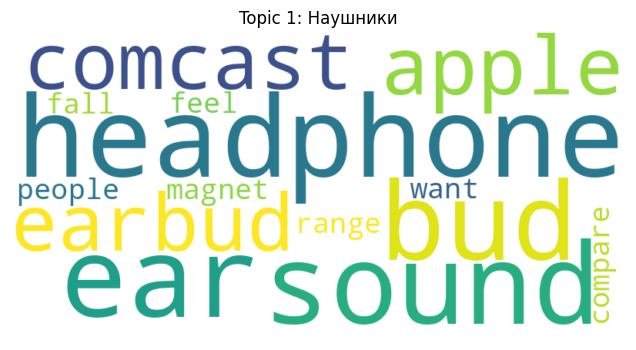

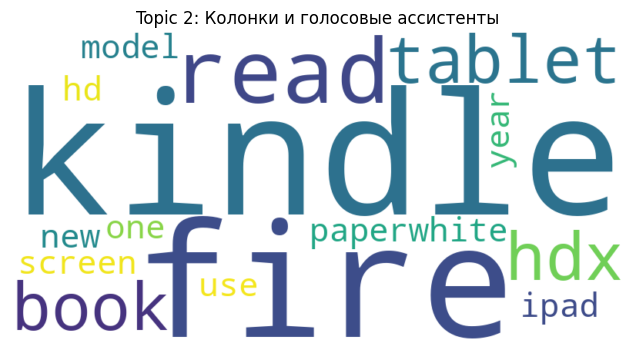

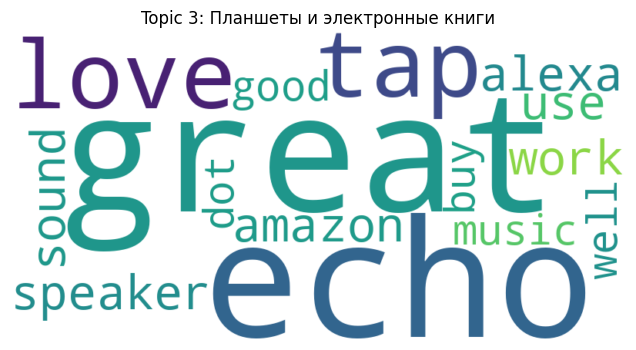

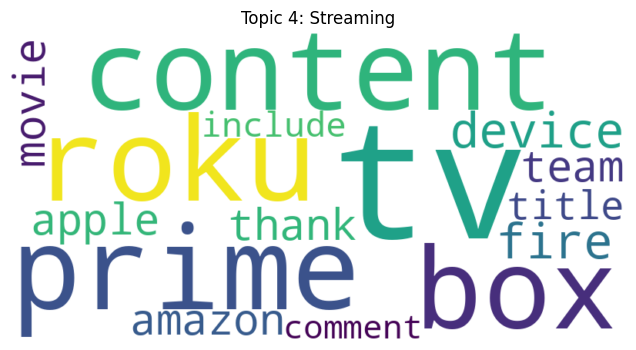

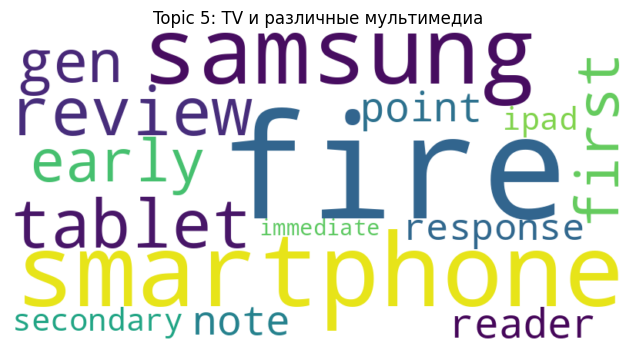

In [ ]:

feature_names = tfidf_vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda.components_):
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(
        " ".join([feature_names[i] for i in topic.argsort()[:-15 - 1:-1]])
    )
    plt.figure(figsize=(8, 4))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Topic {topic_idx+1}: {topic_labels[topic_idx+1]}")
    plt.show()


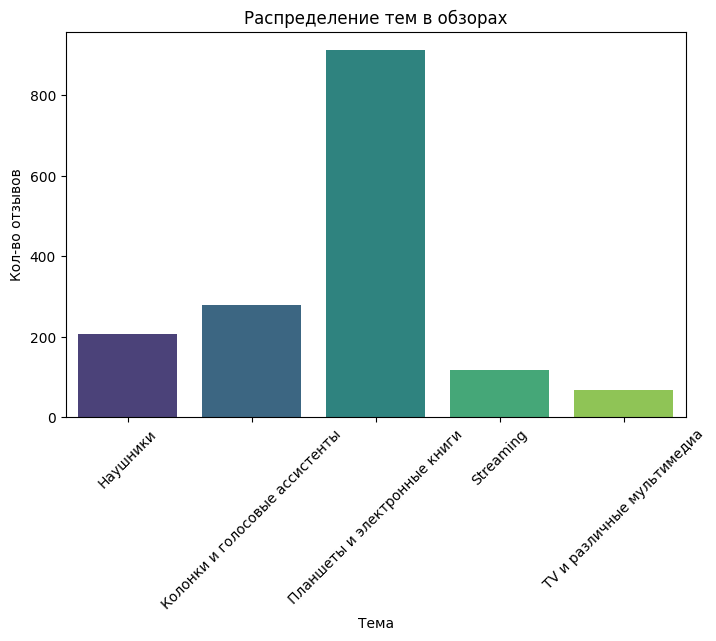

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x=df['topic'], palette="viridis")


ax.set_xticklabels([topic_labels[i] for i in sorted(df['topic'].unique())], rotation=45)

plt.xlabel("Тема")
plt.ylabel("Кол-во отзывов")
plt.title("Распределение тем в обзорах")
plt.show()

In [ ]:
#Фильтрация отзывов по теме
headphones_reviews = df[df['topic'] == 1]  #можно выбрать один из 5
print(headphones_reviews[['reviews.text', 'topic_label']].head())

                                         reviews.text topic_label
16  Vraiment bon petit appareil , lger et facile d...    Наушники
56  I'm your typical middle-aged woman - I don't g...    Наушники
59  I'm your typical middle-aged woman - I don't g...    Наушники
62  I'm your typical middle-aged woman - I don't g...    Наушники
63  I'm your typical middle-aged woman - I don't g...    Наушники


In [ ]:
# Сохраняем только нужные столбцы в CSV
headphones_reviews[['reviews.text', 'topic_label']].to_csv('headphones_reviews.csv', index=False)
from google.colab import files
files.download('headphones_reviews.csv')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



---


# Немного про сохранение файлов.

Чтобы сохранить нужный раздел тем отзывов к себе на устройство, нужно:


1.   Найти в предыдущем окне кода команду "headphones_reviews = df[df['topic'] == 1]"
2.   Далее, меняем "== 1" на "== 2" или другое значение согласно списку.

Список:

    1: "Наушники",
    2: "Колонки и голосовые ассистенты",
    3: "Планшеты и электронные книги",
    4: "Streaming",
    5: "TV и различные мультимедиа"




В конце, хотелось бы сказать. Если вы хотите адаптировать этот код под свой бизнес или товар, то для начала изучите датасет с отзывами. Либо напишите нам на почту, мы поможем) Спасибо за внимание.
Проект так же будет размещен на GIT-HUB.


---

